# ETL — Carga de productos para Huellitas Pet Shop

---

## Objetivo

Poblar la tabla `producto` de la base de datos de **Huellitas** con datos reales y limpios,
obtenidos del dataset público de Amazon Pet Supplies (McAuley Lab, UCSD, 2023).

El pipeline realiza las siguientes etapas:

1. **Extracción:** descarga del dataset JSONL oficial desde McAuley Lab.
2. **Carga inicial:** conversión a DataFrame y selección de columnas relevantes.
3. **Transformación:** filtrado, clasificación de categorías, limpieza de marcas, generación de nombres y descripciones en español con Groq (Llama 3).
4. **EDA:** validación de calidad antes de insertar.
5. **Carga:** generación del SQL e inserción directa a Neon.

---

**Tabla destino:** `producto`  
**Campos cargados:** `nombre`, `marca`, `precio`, `img`, `stockActual`, `stockMinimo`, `descripcion`, `idCategoria`  
**Fuente:** [McAuley Lab — Amazon Reviews 2023, Pet Supplies](https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/)  
**Modelo de lenguaje:** Groq API — `llama-3.1-8b-instant`

## 1. Instalacion de dependencias

In [1]:
!pip install -q groq pandas sqlalchemy psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 27.6 MB/s eta 0:00:00


## 2. Imports

In [2]:
import time
import random
import re
import gzip
import json as jsonlib
import urllib.request

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, HTML
from groq import Groq
from google.colab import userdata, files

print('Imports OK.')

Imports OK.


## 3. Constantes

In [3]:
LIMITE_PRODUCTOS = 500

MAX_LEN_NOMBRE = 100
MAX_LEN_MARCA  = 100
MAX_LEN_IMG    = 255

PRECIO_POR_CATEGORIA = {
    1: (15000, 45000),
    2: (8000,  25000),
    3: (12000, 40000),
    4: (3500,  12000),
    5: (35000, 95000),
    6: (6000,  20000),
    7: (5000,  18000),
    8: (4000,  15000),
}

CAT_NOMBRES = {
    1: 'Farmacia',
    2: 'Higiene',
    3: 'Alimentos',
    4: 'Juguetes',
    5: 'Camas/Hogar',
    6: 'Paseo/Ropa',
    7: 'Accesorios',
    8: 'Aves',
}

ANIMALES_PROHIBIDOS = [
    'hamster', 'guinea pig', 'gerbil', 'chinchilla', 'ferret',
    'rat ', 'rats ', 'mouse ', 'mice ', 'rodent', 'rabbit', 'bunny',
    'squirrel', 'hedgehog', 'sugar glider',
    'reptile', 'lizard', 'gecko', 'snake', 'turtle', 'tortoise',
    'frog', 'toad', 'iguana', 'chameleon',
    'cow', 'cattle', 'buffalo', 'calf', 'bull',
    'horse', 'pony', 'goat', 'sheep', 'lamb',
    'pig ', 'swine', 'poultry farm', 'livestock',
    'milk production', 'dairy',
    'aquarium', 'goldfish', 'betta', 'cichlid', 'aquatic', 'fish food',
    'ant nest', 'insect',
]

AVES_GRANJA = [
    'chicken diapers', 'chicken beak', 'chicken arms',
    'poultry nipple', 'poultry drinker', 'chicken drinker',
    'poultry leg band', 'chicken vegetable hanging',
]

EXCEPCIONES_INGREDIENTE = ['flavor', 'flavour', 'taste', 'ingredient']

print('Constantes definidas.')

Constantes definidas.


## 4. Descarga del dataset

In [4]:
URL_JSONL = (
    'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/'
    'raw/meta_categories/meta_Pet_Supplies.jsonl.gz'
)

DESTINO = '/content/meta_Pet_Supplies.jsonl.gz'

print('Descargando meta_Pet_Supplies.jsonl.gz desde McAuley Lab...')
print('(Archivo de ~200MB — tarda 2-5 minutos segun conexion)')
urllib.request.urlretrieve(URL_JSONL, DESTINO)
print('Descarga completada.')

Descargando meta_Pet_Supplies.jsonl.gz desde McAuley Lab...
(Archivo de ~200MB — tarda 2-5 minutos segun conexion)
Descarga completada.


## 5. Conversion a DataFrame

In [5]:
registros = []

print('Leyendo JSONL...')
with gzip.open(DESTINO, 'rt', encoding='utf-8') as f:
    for linea in f:
        try:
            item = jsonlib.loads(linea.strip())
        except Exception:
            continue

        img_url = ''
        for img in item.get('images', []):
            candidato = img.get('large') or img.get('hi_res') or img.get('thumb') or ''
            if candidato.startswith('http'):
                img_url = candidato
                break

        cats = item.get('categories', [])
        categoria_raw = ' | '.join(str(c) for c in cats) if cats else ''

        registros.append({
            'asin':        str(item.get('parent_asin') or item.get('asin') or ''),
            'title':       str(item.get('title') or ''),
            'store':       str(item.get('store') or ''),
            'img':         img_url[:MAX_LEN_IMG],
            'categories':  categoria_raw,
            'description': ' '.join(item.get('description') or [])[:500],
        })

df_raw = pd.DataFrame(registros)
df_raw = df_raw[
    (df_raw['title'].str.strip() != '') &
    (df_raw['title'] != 'nan') &
    (df_raw['img'].str.startswith('http', na=False))
].copy()
df_raw.reset_index(drop=True, inplace=True)

print(f'Registros con titulo e imagen: {len(df_raw)}')
pd.set_option('display.max_colwidth', 70)
display(df_raw[['title', 'store', 'img', 'categories', 'description']].head(5))

Leyendo JSONL...
Registros con titulo e imagen: 492729


,title,store,img,categories,description
0,"Hurtta Pet Collection 14-Inch Padded Y-Harness, Pink",Hurtta,https://m.media-amazon.com/images/I/51t7obbDd+L._AC_.jpg,"Pet Supplies | Dogs | Collars, Harnesses & Leashes | Harnesses | V...","Hurtta harnesses are suitable for active walks for all dogs, but t..."
1,"Raised Dog Bowls,6 Inch Ceramic Dog Bowl Dish, with Metal Stand an...",FIVEAGE,https://m.media-amazon.com/images/I/31r9jsuUe0S._AC_.jpg,Pet Supplies | Dogs | Feeding & Watering Supplies | Bowls & Dishes...,
2,4 Pack - 4 Inch Ring Filter Socks 200 Micron - Aquarium Felt Filte...,Encompass All,https://m.media-amazon.com/images/I/31T4ekKFOrL._AC_.jpg,,"Micron filter bags provide excellent mechanical filtration, which ..."
3,"SlowTon Dog Vest Harness, Mesh Breathable Pet Harness with Adjusta...",SlowTon,https://m.media-amazon.com/images/I/51ZLo1hIanL._AC_.jpg,"Pet Supplies | Dogs | Collars, Harnesses & Leashes | Harnesses | V...",
4,Cat Window Perch Durable Cat Hammock Seat for Indoor Cats Reversib...,Mewoo,https://m.media-amazon.com/images/I/41y1zgIZtGL._AC_.jpg,Pet Supplies | Cats | Beds & Furniture | Hammocks,


## 6. Funciones de limpieza y clasificacion

In [6]:
def es_producto_valido(row):
    texto = (str(row['title']) + ' ' + str(row['categories'])).lower()
    for termino in ANIMALES_PROHIBIDOS:
        if termino in texto:
            if any(exc in texto for exc in EXCEPCIONES_INGREDIENTE):
                continue
            return False
    titulo_lower = str(row['title']).lower()
    for termino in AVES_GRANJA:
        if termino in titulo_lower:
            return False
    return True


def limpiar_marca(valor):
    if pd.isna(valor) or str(valor).strip() in ('', 'nan', 'None'):
        return 'Sin marca'
    texto = str(valor).strip()
    match_store = re.match(r'(?i)visit\s+the\s+(.+?)\s+store$', texto)
    if match_store:
        return match_store.group(1).strip()
    texto = re.sub(r'(?i)^brand:\s*', '', texto).strip()
    if texto.lower() in ('generic', 'generico', 'nan', 'n/a', 'unknown', ''):
        return 'Sin marca'
    return texto[:MAX_LEN_MARCA]


def clasificar_categoria(categories, title):
    texto = (str(categories) + ' ' + str(title)).lower()

    # 1. FARMACIA / SALUD
    if any(x in texto for x in [
        'medic', 'medicine', 'medication', 'pharmaceutical',
        'health', 'healthcare', 'wellness', 'therapeutic',
        'vitamin', 'supplement', 'probiotic', 'omega',
        'flea', 'tick', 'parasite', 'antiparasitic', 'dewormer', 'wormer',
        'dental', 'teeth', 'tooth', 'oral care', 'breath',
        'recovery', 'rehabilitation', 'cone', 'elizabethan collar',
        'eye drop', 'ear drop', 'antiseptic', 'wound', 'bandage',
        'joint', 'arthritis', 'pain relief', 'anti-inflammatory',
        'anxiety', 'calming', 'sedative', 'pheromone',
        'allergy', 'antihistamine', 'skin condition',
    ]):
        return 1

    # 2. HIGIENE / GROOMING
    if any(x in texto for x in [
        'shampoo', 'conditioner', 'soap', 'bath', 'bathing',
        'groom', 'grooming', 'brush', 'comb', 'deshedding', 'detangler',
        'wipe', 'wet wipe', 'cleaning wipe', 'towel',
        'nail', 'clipper', 'trimmer', 'scissors', 'clippers',
        'litter', 'litter box', 'cat litter', 'sand', 'clumping',
        'scoop', 'scooper', 'pooper', 'poop bag', 'waste bag', 'doggy bag',
        'diaper', 'belly band', 'sanitary',
        'deodorant', 'odor', 'odour', 'freshener', 'eliminator',
        'dryer', 'blow dry',
    ]):
        return 2

    # 3. ALIMENTOS / NUTRICION
    if any(x in texto for x in [
        'food', 'dry food', 'wet food', 'kibble', 'pate',
        'treat', 'treats', 'snack', 'reward', 'biscuit', 'chew treat',
        'nutrition', 'nutritional', 'diet', 'formula',
        'bowl', 'dish', 'feeder', 'auto feeder', 'slow feeder',
        'waterer', 'water fountain', 'dispenser', 'drinker',
        'raw food', 'freeze dried', 'dehydrated', 'grain free',
        'puppy food', 'kitten food', 'senior food', 'adult food',
        'supplement food', 'topper', 'meal topper',
    ]):
        return 3

    # 4. JUGUETES / ENTRETENIMIENTO
    if any(x in texto for x in [
        'toy', 'toys', 'plaything', 'play',
        'ball', 'fetch', 'frisbee', 'rope toy', 'tug',
        'chew', 'chew toy', 'teether', 'nylabone',
        'scratch', 'scratcher', 'scratching post', 'cat tree', 'cat tower',
        'teaser', 'wand', 'feather wand', 'laser', 'pointer',
        'tunnel', 'playhouse', 'interactive',
        'puzzle', 'enrichment', 'lick mat', 'snuffle mat',
        'squeaky', 'squeaker', 'plush toy', 'stuffed',
        'swing', 'perch', 'ladder', 'bird toy',
        'game', 'activity',
    ]):
        return 4

    # 5. CAMAS / HOGAR
    if any(x in texto for x in [
        'bed', 'beds', 'sleeping', 'sleep',
        'mat', 'mattress', 'cushion', 'pillow', 'pad',
        'blanket', 'throw', 'fleece',
        'hammock', 'hanging bed',
        'crate', 'kennel', 'playpen', 'pen', 'enclosure',
        'house', 'igloo', 'cave', 'hideout', 'den', 'hut',
        'carrier', 'crate carrier', 'travel bag', 'airline',
        'stroller', 'pram', 'cart',
        'cage', 'birdcage', 'habitat', 'hutch', 'terrarium',
        'nest', 'nesting',
        'ramp', 'stairs', 'steps',
    ]):
        return 5

    # 6. PASEO / VIAJE
    if any(x in texto for x in [
        'leash', 'lead', 'slip lead', 'retractable leash', 'bungee leash',
        'harness', 'walking harness', 'no pull', 'front clip',
        'walking', 'outdoor', 'hiking', 'trail', 'adventure',
        'seat belt', 'car restraint', 'travel restraint',
        'life jacket', 'life vest', 'flotation',
        'bike', 'bicycle', 'cycling',
        'gps', 'tracker', 'locator',
    ]):
        return 6

    # 7. ACCESORIOS / INDUMENTARIA
    if any(x in texto for x in [
        'collar', 'flea collar', 'breakaway collar', 'martingale',
        'id tag', 'tag', 'name tag', 'engraved', 'personalized tag',
        'bandana', 'scarf', 'neckerchief',
        'vest', 'apparel', 'clothing', 'outfit', 'costume', 'halloween',
        'shirt', 't-shirt', 'hoodie', 'sweater', 'coat', 'jacket',
        'raincoat', 'pyjama', 'pajama', 'dress', 'skirt',
        'boots', 'shoes', 'socks', 'booties', 'paw protection',
        'backpack', 'saddlebag',
        'bow', 'ribbon', 'hair clip', 'hair tie',
        'training', 'clicker', 'whistle', 'target stick',
        'gate', 'fence', 'barrier', 'door',
        'camera', 'monitor', 'bell',
        'clip', 'hook', 'buckle', 'attachment',
    ]):
        return 7

    return 7


def precio_por_categoria(id_categoria):
    rango = PRECIO_POR_CATEGORIA.get(id_categoria, (5000, 20000))
    return random.randint(*rango)


print('Funciones definidas.')

Funciones definidas.


## 7. Configuracion de Groq API

In [12]:
client = Groq(api_key=userdata.get('GROQ_API_KEY'))

SYSTEM_NOMBRE = (
    'Eres redactor de catalogo para Huellitas, una tienda online de mascotas argentina. '
    'Genera el nombre comercial del producto en espanol rioplatense. '
    'REGLAS OBLIGATORIAS: maximo 80 caracteres. '
    'Solo la primera letra del nombre en mayuscula, el resto en minuscula. '
    'Sin marca en el nombre. Sin codigos de modelo ni referencias internas. '
    'Sin medidas ni pesos (no incluir 2kg, 500ml, Large, XL). '
    'Sin parentesis de color o talle. Sin signos de exclamacion. '
    'NO incluir para perros, para gatos, para mascotas ni ningun animal en el nombre. '
    'El nombre describe QUE ES el producto, no para quien es. '
    'Usa vocabulario argentino: correa (no lazo), arnes (no vestidor), comedero (no bowl). '
    'EJEMPLOS CORRECTOS: '
    'KONG Classic Dog Toy Large Red -> Juguete Kong classic. '
    'Retractable Cat Wand Orange -> Varita retractil interactiva. '
    'SlowTon Dog Vest Harness Adjustable -> Arnes chaleco ajustable. '
    'K9PROLINE Professional Dog Leash 6ft -> Correa profesional resistente. '
    'Raised Dog Bowl with Metal Stand -> Comedero elevado con soporte metalico. '
    'Wysong Optimal Adult Canine Dry Food -> Alimento seco para adultos. '
    'Bone Broth Mobility Formula Dogs Cats -> Caldo de huesos con colageno. '
    'EJEMPLOS INCORRECTOS (nunca hacer esto): '
    'Lazo para perros. / Vestidor ajustable para perros. / Caldo Primalvore. / Optima 365. '
    'Responde SOLO con el nombre. Sin comillas ni explicaciones.'
)

SYSTEM_DESC = (
    'Eres redactor de catalogo para Huellitas, una tienda online de mascotas argentina. '
    'Redacta una descripcion comercial del producto en espanol rioplatense. '
    'REGLAS: maximo 500 caracteres. Tono amigable y natural,sin simbolos de exclamacion.'
    'Sin mencionar marca, precio, ni medidas exactas. '
    'Destacar beneficios para la mascota y el duenioo. '
    'Responde SOLO con la descripcion. Sin comillas ni explicaciones.'
)


def generar_nombre(title, marca, delay=0.05):
    prompt = f'Marca: {marca}\nTitulo: {title}'
    try:
        time.sleep(delay)
        response = client.chat.completions.create(
            model='llama-3.1-8b-instant',
            max_tokens=60,
            temperature=0.3,
            messages=[
                {'role': 'system', 'content': SYSTEM_NOMBRE},
                {'role': 'user',   'content': prompt}
            ]
        )
        nombre = response.choices[0].message.content.strip()
        return nombre.replace("'", '').replace('"', '')[:MAX_LEN_NOMBRE]
    except Exception as e:
        print(f"  Error nombre en '{title[:40]}': {e}")
        return ' '.join(title.split()[:6])[:MAX_LEN_NOMBRE]


def generar_descripcion(title, marca, desc_raw, delay=0.05):
    contexto = f'Descripcion original: {desc_raw.strip()}\n' if desc_raw and len(desc_raw.strip()) > 30 else ''
    prompt = f'{contexto}Marca: {marca}\nProducto: {title}'
    try:
        time.sleep(delay)
        response = client.chat.completions.create(
            model='llama-3.1-8b-instant',
            max_tokens=120,
            temperature=0.4,
            messages=[
                {'role': 'system', 'content': SYSTEM_DESC},
                {'role': 'user',   'content': prompt}
            ]
        )
        return response.choices[0].message.content.strip()[:500]
    except Exception as e:
        print(f"  Error desc en '{title[:40]}': {e}")
        return ''


print('Cliente Groq configurado — modelo: llama-3.1-8b-instant')

Cliente Groq configurado — modelo: llama-3.1-8b-instant


## 8. Pipeline principal

Filtrar

In [13]:
mascara = df_raw.apply(es_producto_valido, axis=1)
df = df_raw[mascara].copy()
df.reset_index(drop=True, inplace=True)
print(f'  Originales : {len(df_raw)}')
print(f'  Eliminados : {len(df_raw) - len(df)}')
print(f'  Validos    : {len(df)}')



  Originales : 492729
  Eliminados : 102611
  Validos    : 390118


Limitar y transformar

In [14]:
print(f'\nPaso 2: Tomando {LIMITE_PRODUCTOS} productos...')
df = df.head(LIMITE_PRODUCTOS).copy()
df['marca']       = df['store'].apply(limpiar_marca)
df['stockActual'] = [random.randint(3, 50) for _ in range(len(df))]
df['stockMinimo'] = 5


Paso 2: Tomando 500 productos...


Catregorias

In [15]:

print('\nPaso 3: Clasificando categorias...')
df['idCategoria'] = df.apply(
    lambda row: clasificar_categoria(row['categories'], row['title']), axis=1
)
df['precio'] = df['idCategoria'].apply(precio_por_categoria)

for cat_id, count in df['idCategoria'].value_counts().sort_index().items():
    print(f'    {cat_id} — {CAT_NOMBRES.get(cat_id, "?")}: {count}')


Paso 3: Clasificando categorias...
    1 — Farmacia: 80
    2 — Higiene: 38
    3 — Alimentos: 70
    4 — Juguetes: 56
    5 — Camas/Hogar: 92
    6 — Paseo/Ropa: 98
    7 — Accesorios: 66


Generar nombres

In [16]:
print(f'\nPaso 4: Generando {len(df)} nombres con Groq API...')
nombres = []
for i, (_, row) in enumerate(df.iterrows(), 1):
    if i % 25 == 0:
        print(f'  -> {i}/{len(df)} listos...')
    nombres.append(generar_nombre(row['title'], row['marca']))
df['nombre'] = nombres


Paso 4: Generando 500 nombres con Groq API...
  -> 25/500 listos...
  -> 50/500 listos...
  -> 75/500 listos...
  -> 100/500 listos...
  -> 125/500 listos...
  -> 150/500 listos...
  -> 175/500 listos...
  -> 200/500 listos...
  -> 225/500 listos...
  -> 250/500 listos...
  -> 275/500 listos...
  -> 300/500 listos...
  -> 325/500 listos...
  -> 350/500 listos...
  -> 375/500 listos...
  -> 400/500 listos...
  -> 425/500 listos...
  -> 450/500 listos...
  -> 475/500 listos...
  -> 500/500 listos...


Generar descripciones

In [17]:
print(f'\nPaso 5: Generando {len(df)} descripciones con Groq API...')
descripciones = []
for i, (_, row) in enumerate(df.iterrows(), 1):
    if i % 25 == 0:
        print(f'  -> {i}/{len(df)} listas...')
    descripciones.append(generar_descripcion(row['title'], row['marca'], row['description']))
df['descripcion'] = descripciones

print(f'\nPipeline completado. {len(df)} productos.')
pd.set_option('display.max_colwidth', 85)
display(df[['title', 'nombre', 'descripcion', 'marca', 'idCategoria', 'precio']].head(10))


Paso 5: Generando 500 descripciones con Groq API...
  -> 25/500 listas...
  -> 50/500 listas...
  -> 75/500 listas...
  -> 100/500 listas...
  -> 125/500 listas...
  -> 150/500 listas...
  -> 175/500 listas...
  -> 200/500 listas...
  -> 225/500 listas...
  -> 250/500 listas...
  -> 275/500 listas...
  -> 300/500 listas...
  -> 325/500 listas...
  -> 350/500 listas...
  -> 375/500 listas...
  -> 400/500 listas...
  -> 425/500 listas...
  -> 450/500 listas...
  -> 475/500 listas...
  -> 500/500 listas...

Pipeline completado. 500 productos.


,title,nombre,descripcion,marca,idCategoria,precio
0,"Hurtta Pet Collection 14-Inch Padded Y-Harness, Pink",Arnes chaleco con relleno.,El Hurtta Pet Collection es un arnés cómodo y seguro para paseos activos de tu ma...,Hurtta,5,39447
1,"Raised Dog Bowls,6 Inch Ceramic Dog Bowl Dish, with Metal Stand and Grey Silicone...",Comedero elevado con soporte metalico y tapa de silicona.,"""Alimenta a tu mascota con estilo y comodidad. Nuestro conjunto de platos para pe...",FIVEAGE,1,24671
2,"SlowTon Dog Vest Harness, Mesh Breathable Pet Harness with Adjustable Neck and Ch...",Arenes chaleco ajustable.,El SlowTon Dog Vest Harness es una solución cómoda y segura para tus paseos con t...,SlowTon,1,18126
3,Cat Window Perch Durable Cat Hammock Seat for Indoor Cats Reversible Mat Use Year...,Asiento de ventana duradero.,"Descubre la comodidad perfecta para tu gatito con nuestro cat window perch, ideal...",Mewoo,2,21312
4,"ROZKITCH Squeaky Water Bottle Toy, No Stuffing Squeak Toy Crackle and Crunch with...",Botella ruidosa con inserto de botella vacía.,Descubre el juguete de agua que hará que tu perro se divierta sin parar. Este jug...,ROZKITCH,4,11013
5,AIMTOPPY Fashion Christmas Snowman Pet Clothes for Dog Cat Puppy Hoodies Coat Win...,Chaleco de invierno abrigado,Este adorable abrigo de invierno para perros y gatos es perfecto para mantener a ...,AIMTOPPY,7,13889
6,"Dog Bike Trailer - Durable Frame - Easy to Connect and Disconnect to Bicycles, Sa...",Remolque bicicleta portamascotas resistente.,Descubre la forma divertida y segura de llevar a tu mascota en bicicleta. Nuestro...,ANOUR,5,48541
7,"Wysong Optimal Adult Canine Formula Dry Dog Food- 5 Pound Bag, Model: WDCOA5",Alimento seco para adultos.,Nuestra comida seca para perros es una opción natural y saludable para tu mascota...,Wysong,3,29566
8,"K9PROLINE [Waterproof] Professional Dog Leash - Thick Soft Grip, Strong 6ft. Leas...",Correa profesional resistente,"La serie Alpha es nuestra línea de productos de alta gama, fabricados con BioThan...",K9PROLINE,6,9843
9,Shed Pal Pet Hair Remover Dog Cat Grooming Vacuum System Clean Fur Popular Items,Sistema de limpieza de pelo.,Descubre la solución perfecta para el pelaje de tus mascotas. El Shed Pal es un s...,Sin marca,2,23640


In [18]:
df['descripcion'] = df['descripcion'].str.lstrip('¡')

## 9. Verificacion visual de imagenes

In [19]:
def verificar_imagenes(df, n=10, categoria=None):
    muestra = df if categoria is None else df[df['idCategoria'] == categoria]
    muestra = muestra.sample(min(n, len(muestra)))
    html = ''
    for _, row in muestra.iterrows():
        precio_fmt = f"${row['precio']:,}".replace(',', '.')
        html += f"""
        <div style="display:inline-block; margin:10px; text-align:center;
                    width:200px; vertical-align:top; border:1px solid #ddd;
                    padding:8px; border-radius:8px">
            <img src="{row['img']}" width="180" height="180"
                 style="object-fit:contain"
                 onerror="this.src='https://via.placeholder.com/180?text=Sin+imagen'"/>
            <p style="font-size:12px; margin:6px 0"><b>{row['nombre']}</b></p>
            <p style="font-size:11px; color:gray">{CAT_NOMBRES.get(row['idCategoria'], '?')} | {row['marca']}</p>
            <p style="font-size:11px; color:green">{precio_fmt}</p>
        </div>
        """
    display(HTML(html))

# Muestra general
verificar_imagenes(df, n=10)

## 10. EDA — Analisis exploratorio

> Revisar todo antes de generar el SQL. Para corregir un nombre puntual:
> ```python
> df.at[5, 'nombre'] = 'Arnes ajustable'
> ```

Setup

In [20]:
sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
print('Setup EDA listo.')
print(f'Dataset: {len(df)} productos — {df["idCategoria"].nunique()} categorias — {df["marca"].nunique()} marcas')

Setup EDA listo.
Dataset: 500 productos — 7 categorias — 443 marcas


Tratamiento de nulos y vacios

In [21]:
print('=' * 50)
print('  NULOS Y VACIOS POR COLUMNA')
print('=' * 50)
cols = ['nombre', 'marca', 'img', 'descripcion', 'precio', 'idCategoria', 'stockActual']
for col in cols:
    nulos  = df[col].isna().sum()
    vacios = (df[col].astype(str).str.strip() == '').sum()
    total  = nulos + vacios
    estado = 'OK' if total == 0 else 'REVISAR'
    print(f'  {estado}  {col:15} — nulos: {nulos:3}  |  vacios: {vacios:3}  |  total: {total:3}')

  NULOS Y VACIOS POR COLUMNA
  OK  nombre          — nulos:   0  |  vacios:   0  |  total:   0
  OK  marca           — nulos:   0  |  vacios:   0  |  total:   0
  OK  img             — nulos:   0  |  vacios:   0  |  total:   0
  OK  descripcion     — nulos:   0  |  vacios:   0  |  total:   0
  OK  precio          — nulos:   0  |  vacios:   0  |  total:   0
  OK  idCategoria     — nulos:   0  |  vacios:   0  |  total:   0
  OK  stockActual     — nulos:   0  |  vacios:   0  |  total:   0


Longitud de nombre y descripcion

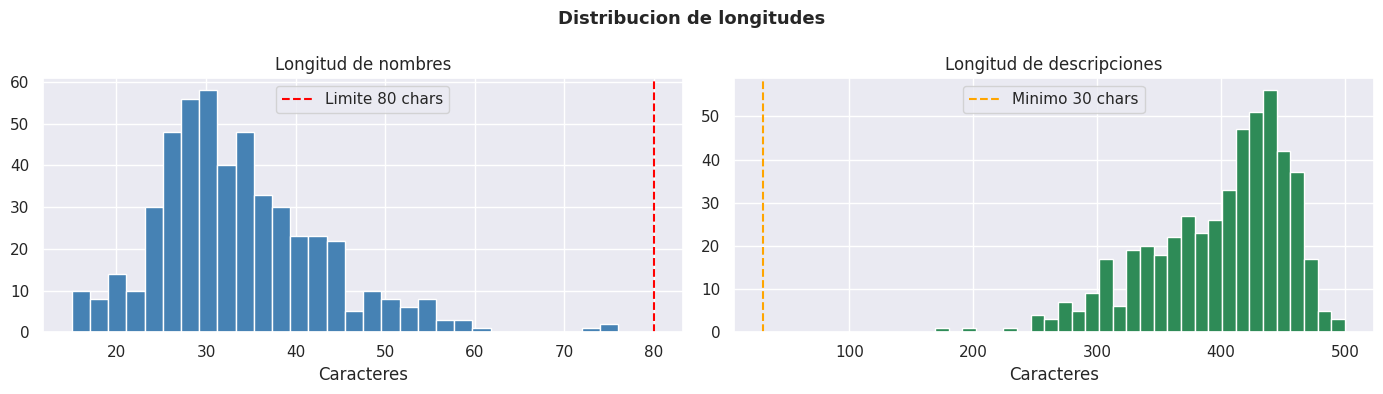

Nombres > 80 chars      : 0
Nombres < 10 chars      : 0
Descripciones < 30 chars: 0
Descripciones vacias    : 0


In [22]:
df['len_nombre'] = df['nombre'].str.len()
df['len_desc']   = df['descripcion'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['len_nombre'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(80, color='red', linestyle='--', linewidth=1.5, label='Limite 80 chars')
axes[0].set_title('Longitud de nombres')
axes[0].set_xlabel('Caracteres')
axes[0].legend()

df['len_desc'].hist(bins=30, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].axvline(30, color='orange', linestyle='--', linewidth=1.5, label='Minimo 30 chars')
axes[1].set_title('Longitud de descripciones')
axes[1].set_xlabel('Caracteres')
axes[1].legend()

plt.suptitle('Distribucion de longitudes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Nombres > 80 chars      : {(df["len_nombre"] > 80).sum()}')
print(f'Nombres < 10 chars      : {(df["len_nombre"] < 10).sum()}')
print(f'Descripciones < 30 chars: {(df["len_desc"] < 30).sum()}')
print(f'Descripciones vacias    : {(df["descripcion"].str.strip() == "").sum()}')

problemas = df[df['len_nombre'] < 10][['nombre', 'marca', 'idCategoria']]
if len(problemas) > 0:
    print('\nNombres muy cortos (revisar):')
    display(problemas)

Productos por categoria

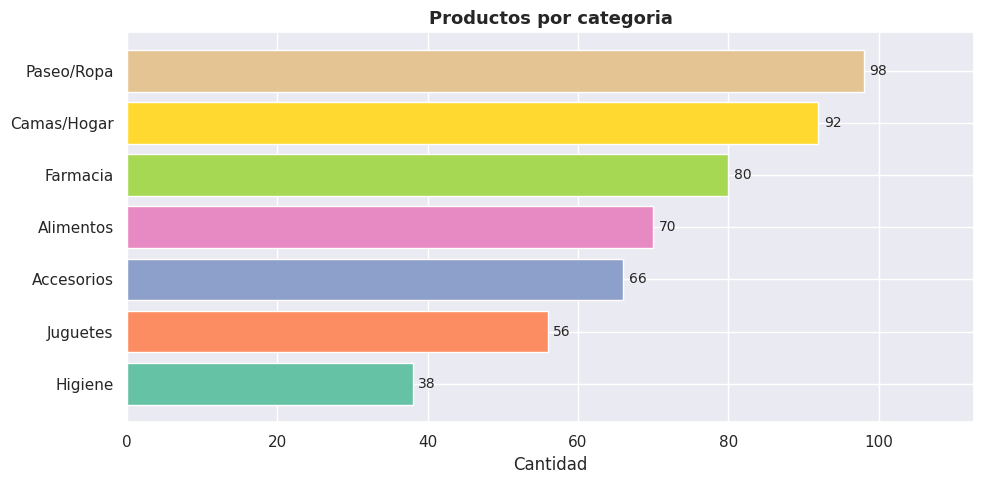

cat_nombre
Accesorios     66
Alimentos      70
Camas/Hogar    92
Farmacia       80
Higiene        38
Juguetes       56
Paseo/Ropa     98

Total: 500


In [23]:
df['cat_nombre'] = df['idCategoria'].map(CAT_NOMBRES)
conteo = df['cat_nombre'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(conteo.index, conteo.values, color=sns.color_palette('Set2', len(conteo)))
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title('Productos por categoria', fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad')
ax.set_xlim(0, conteo.max() * 1.15)
plt.tight_layout()
plt.show()

print(conteo.sort_index().to_string())
print(f'\nTotal: {conteo.sum()}')

Reclasificar elementos en farmacia

In [30]:
mask_farmacia = df['idCategoria'] == 1

df.loc[mask_farmacia, 'idCategoria'] = df[mask_farmacia].apply(
    lambda row: clasificar_categoria(row['nombre'], row['descripcion']), axis=1
)

# Ver resultado
print("Distribución después de reclasificación:")
print(df['idCategoria'].map(CAT_NOMBRES).value_counts())

Distribución después de reclasificación:
idCategoria
Camas/Hogar    111
Paseo/Ropa     100
Accesorios      96
Alimentos       75
Juguetes        59
Higiene         40
Farmacia        19
Name: count, dtype: int64


Distribucion de precios por categoria

/tmp/ipykernel_1894/3030112203.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cat_nombre', y='precio', palette='Set2', ax=axes[0])


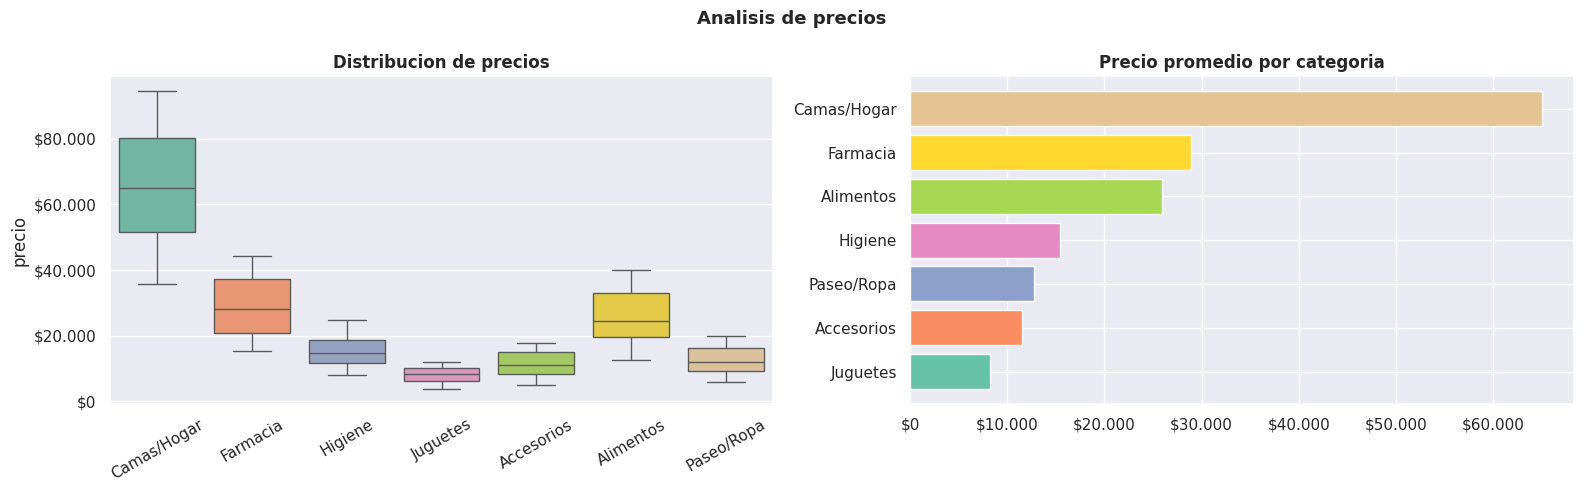

               min     mean    max
cat_nombre                        
Accesorios    5004  11484.0  17920
Alimentos    12684  25886.0  39995
Camas/Hogar  35700  65083.0  94472
Farmacia     15392  28918.0  44427
Higiene       8112  15393.0  24720
Juguetes      3778   8263.0  11979
Paseo/Ropa    6012  12779.0  19925


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='cat_nombre', y='precio', palette='Set2', ax=axes[0])
axes[0].set_title('Distribucion de precios', fontweight='bold')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'.replace(',', '.')))
axes[0].tick_params(axis='x', rotation=30)

promedio = df.groupby('cat_nombre')['precio'].mean().sort_values(ascending=True)
axes[1].barh(promedio.index, promedio.values, color=sns.color_palette('Set2', len(promedio)))
axes[1].set_title('Precio promedio por categoria', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'.replace(',', '.')))

plt.suptitle('Analisis de precios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('cat_nombre')['precio'].agg(['min', 'mean', 'max']).round(0).to_string())

Top Marcas

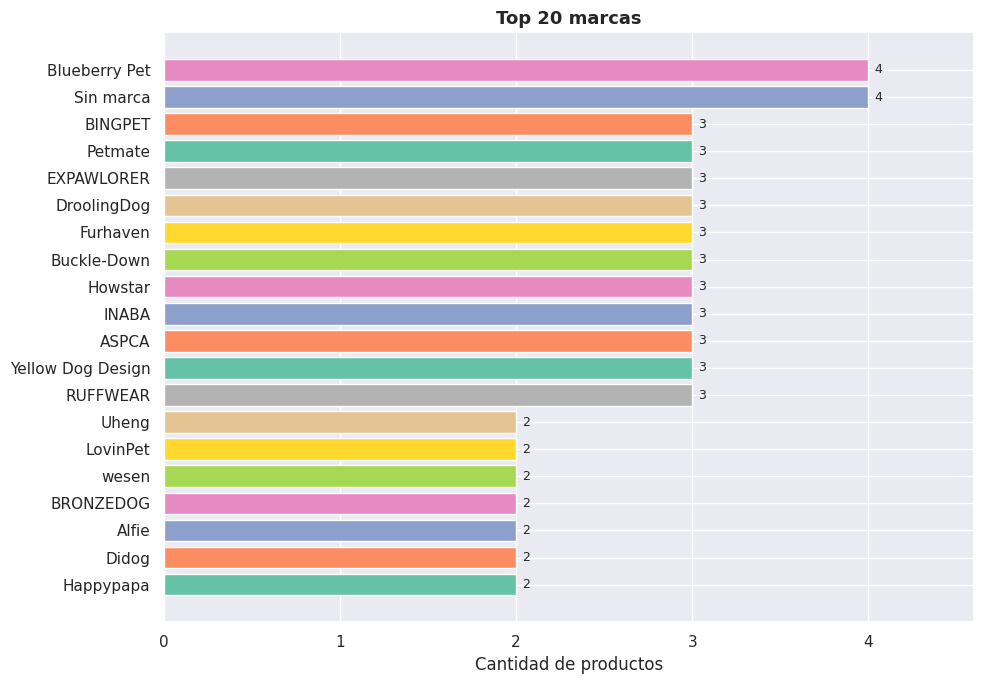

Marcas unicas : 443
Sin marca     : 4 (0.8%)


In [25]:
top_n     = 20
top_marcas = df['marca'].value_counts().head(top_n)
sin_marca  = (df['marca'] == 'Sin marca').sum()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_marcas.index[::-1], top_marcas.values[::-1],
               color=sns.color_palette('Set2', top_n))
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title(f'Top {top_n} marcas', fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de productos')
ax.set_xlim(0, top_marcas.max() * 1.15)
plt.tight_layout()
plt.show()

print(f'Marcas unicas : {df["marca"].nunique()}')
print(f'Sin marca     : {sin_marca} ({sin_marca / len(df) * 100:.1f}%)')

Duplicados

In [34]:
print('=' * 50)
print('  ANALISIS DE DUPLICADOS')
print('=' * 50)

dup_asin   = df['asin'].duplicated().sum()
dup_nombre = df['nombre'].duplicated().sum()
dup_img    = df['img'].duplicated().sum()

print(f"  {'OK' if dup_asin   == 0 else 'REVISAR'}  ASINs duplicados   : {dup_asin}")
print(f"  {'OK' if dup_nombre == 0 else 'REVISAR'}  Nombres duplicados : {dup_nombre}")
print(f"  {'OK' if dup_img    == 0 else 'REVISAR'}  Imagenes duplicadas: {dup_img}")

if dup_nombre > 0:
    print('\nNombres repetidos:')
    display(
        df[df['nombre'].duplicated(keep=False)][['nombre', 'marca', 'idCategoria']]
        .sort_values('nombre')
    )

  ANALISIS DE DUPLICADOS
  OK  ASINs duplicados   : 0
  REVISAR  Nombres duplicados : 6
  OK  Imagenes duplicadas: 0

Nombres repetidos:


,nombre,marca,idCategoria
160,Cama cajon suave.,Pet-line,5
403,Cama cajon suave.,akezone,5
92,Cama de pluma suave.,SALUTUYA,5
294,Cama de pluma suave.,PEOPLE&PETS,5
218,Camiseta con estrellas brillantes.,SparkleNation,5
308,Camiseta con estrellas brillantes.,Mirage Pet Products,5
147,Chaquetita reversible impermeable.,IREENUO,5
289,Chaquetita reversible impermeable.,BONAWEN,7
240,Comedero elevado ajustable.,MO HAPPY,3
401,Comedero elevado ajustable.,LuckyPots,3


In [41]:
df.at[265, 'nombre'] = 'Arnés reflectivo ajustable para perros.'
df.at[280, 'nombre'] = 'Arnés reflectivo con agarre para perros.'
df.at[212, 'nombre'] = 'Arnés vestidor reflectivo para perros pequeños.'
df.at[429, 'nombre'] = 'Arnés vestidor ajustable para perros medianos.'
print(f"Duplicados restantes: {df.duplicated(subset='nombre').sum()}")

Duplicados restantes: 0


In [40]:
df.at[403, 'nombre'] = 'Cama cajón suave para perros grandes.'
df.at[294, 'nombre'] = 'Cama de pluma suave para gatos.'
df.at[308, 'nombre'] = 'Camiseta con estrellas para perros pequeños.'
df.at[289, 'nombre'] = 'Chaquetita impermeable reversible para gatos.'
df.at[401, 'nombre'] = 'Comedero elevado ajustable de plástico.'
df.at[355, 'nombre'] = 'Juguete de goma resistente para cachorros.'

# Verificar
print(f"Duplicados restantes: {df.duplicated(subset='nombre').sum()}")

Duplicados restantes: 0


Imagenes

  ANALISIS DE IMAGENES
  OK  Sin HTTPS       : 0
  OK  URLs < 20 chars : 0
   Con HTTPS          : 500


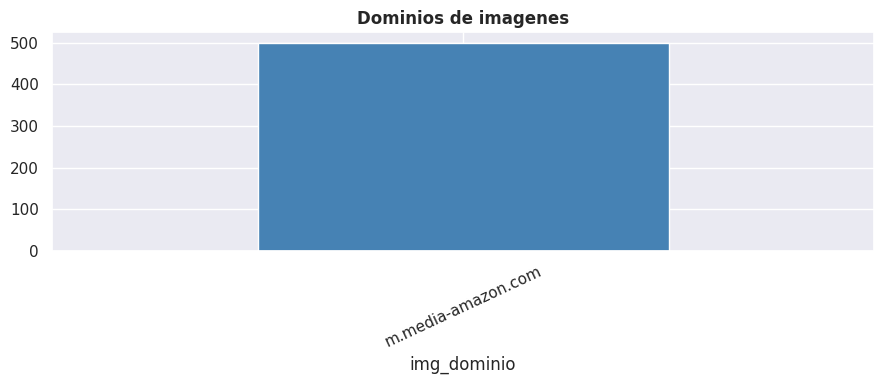

In [42]:
print('=' * 50)
print('  ANALISIS DE IMAGENES')
print('=' * 50)

no_https   = df[~df['img'].str.startswith('https')]
muy_cortas = df[df['img'].str.len() < 20]

print(f"  {'OK' if len(no_https)   == 0 else 'REVISAR'}  Sin HTTPS       : {len(no_https)}")
print(f"  {'OK' if len(muy_cortas) == 0 else 'REVISAR'}  URLs < 20 chars : {len(muy_cortas)}")
print(f'   Con HTTPS          : {df["img"].str.startswith("https").sum()}')

df['img_dominio'] = df['img'].str.extract(r'https?://([^/]+)')
top_dominios = df['img_dominio'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(9, 4))
top_dominios.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Dominios de imagenes', fontweight='bold')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

if len(no_https) > 0:
    print('\nEjemplos sin HTTPS:')
    display(no_https[['nombre', 'img']].head(5))

Resumen Final

In [43]:
print('=' * 55)
print('  RESUMEN FINAL DEL DATASET')
print('=' * 55)
print(f'  Total productos         : {len(df)}')
print(f'  Categorias presentes    : {df["idCategoria"].nunique()} / 8')
print(f'  Marcas unicas           : {df["marca"].nunique()}')
print(f"  Precio promedio         : ${df['precio'].mean():,.0f}".replace(',', '.'))
print(f'  Stock promedio          : {df["stockActual"].mean():.1f} unidades')
print(f'  Imagenes HTTPS          : {df["img"].str.startswith("https").sum()} / {len(df)}')
print(f'  Descripciones vacias    : {(df["descripcion"].str.strip() == "").sum()}')
print(f'  Nombres > 80 chars      : {(df["nombre"].str.len() > 80).sum()}')
print(f'  ASINs duplicados        : {df["asin"].duplicated().sum()}')
print()

errores = [
    df['asin'].duplicated().sum() > 0,
    (~df['img'].str.startswith('https')).sum() > 0,
    (df['nombre'].str.strip() == '').sum() > 0,
    (df['descripcion'].str.strip() == '').sum() > 10,
]

if any(errores):
    print('HAY PROBLEMAS — revisa las celdas anteriores antes de generar el SQL')
else:
    print('TODO OK')

  RESUMEN FINAL DEL DATASET
  Total productos         : 500
  Categorias presentes    : 7 / 8
  Marcas unicas           : 443
  Precio promedio         : $26.342
  Stock promedio          : 25.7 unidades
  Imagenes HTTPS          : 500 / 500
  Descripciones vacias    : 0
  Nombres > 80 chars      : 0
  ASINs duplicados        : 0

TODO OK


## 11. Generacion del SQL — Categorias

In [44]:
NOMBRE_ARCHIVO_CAT = 'huellitas_categorias.sql'

categorias = [
    (1, 'Farmacia',     'Medicamentos, suplementos, antiparasitarios y productos de salud para mascotas.'),
    (2, 'Higiene',      'Shampoos, cepillos, cortaunas, arena sanitaria y productos de limpieza.'),
    (3, 'Alimentos',    'Alimento seco, humedo, snacks, premios y accesorios de alimentacion.'),
    (4, 'Juguetes',     'Juguetes interactivos, pelotas, varas, rascadores y entretenimiento.'),
    (5, 'Camas/Hogar',  'Camas, mantas, jaulas, transportines, casas y accesorios del hogar.'),
    (6, 'Paseo/Ropa',   'Correas, arneses, ropa, accesorios de paseo y viaje.'),
    (7, 'Accesorios',   'Collares, chapitas, mochilas, indumentaria y accesorios varios.'),
    (8, 'Aves',         'Productos especiales para aves: jaulas, perchas, juguetes y alimento.'),
]

with open(NOMBRE_ARCHIVO_CAT, 'w', encoding='utf-8') as f:
    f.write('-- PetShop Huellitas — INSERT categorias\n\n')
    f.write('BEGIN;\n\n')
    for id_cat, nombre, descripcion in categorias:
        f.write(
            f'INSERT INTO categoria ("idCategoria", nombre, descripcion) '
            f"VALUES ({id_cat}, '{nombre}', '{descripcion}');\n"
        )
    f.write('\nCOMMIT;\n')

print(f'Archivo generado: {NOMBRE_ARCHIVO_CAT} — {len(categorias)} categorias')

Archivo generado: huellitas_categorias.sql — 8 categorias


## 12. Generacion del SQL — Productos

In [45]:
def escapar_sql(valor):
    if pd.isna(valor) or valor is None:
        return 'NULL'
    return str(valor).replace("'", "''")


NOMBRE_ARCHIVO = 'huellitas_productos_etl.sql'

with open(NOMBRE_ARCHIVO, 'w', encoding='utf-8') as f:
    f.write('-- PetShop Huellitas — INSERT productos\n')
    f.write('-- Fuente: McAuley Lab Amazon Reviews 2023 — Pet Supplies\n')
    f.write('-- Nombres y descripciones generados con Groq API + Llama 3\n')
    f.write(f'-- Total: {len(df)} registros\n\n')
    f.write('BEGIN;\n\n')

    for _, row in df.iterrows():
        f.write(
            'INSERT INTO producto '
            '(nombre, marca, precio, img, "stockActual", "stockMinimo", descripcion, "idCategoria") '
            'VALUES ('
            f"'{escapar_sql(row['nombre'])}', "
            f"'{escapar_sql(row['marca'])}', "
            f"{int(row['precio'])}, "
            f"'{escapar_sql(row['img'])}', "
            f"{int(row['stockActual'])}, "
            f"{int(row['stockMinimo'])}, "
            f"'{escapar_sql(row['descripcion'])}', "
            f"{int(row['idCategoria'])}"
            ');\n'
        )

    f.write('\nCOMMIT;\n')

print(f'Archivo generado: {NOMBRE_ARCHIVO} — {len(df)} sentencias INSERT')

Archivo generado: huellitas_productos_etl.sql — 500 sentencias INSERT


## 13. Descarga de archivos SQL

In [46]:
files.download(NOMBRE_ARCHIVO_CAT)
files.download(NOMBRE_ARCHIVO)
print('Descarga iniciada.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada.


## 14. Insert directo a Neon (opcional)

Requiere `NEON_URL` en Secrets de Colab.

> **Orden en Neon:**
> 1. `TRUNCATE TABLE producto RESTART IDENTITY CASCADE;`
> 2. Correr `huellitas_categorias.sql`
> 3. Correr `huellitas_productos_etl.sql`

CONEXION

In [47]:
from sqlalchemy import create_engine, text
engine = create_engine(userdata.get('NEON_URL'))

CONSTANTES

In [48]:
CAT_NOMBRES = {
    1: 'Farmacia/Salud',
    2: 'Higiene',
    3: 'Alimentos',
    4: 'Juguetes',
    5: 'Camas/Hogar',
    6: 'Paseo/Viaje',
    7: 'Accesorios',
}

CAT_DESCRIPCIONES = {
    1: 'Productos de salud y bienestar para mascotas',
    2: 'Productos de higiene y grooming',
    3: 'Alimentos, snacks y comederos',
    4: 'Juguetes y entretenimiento',
    5: 'Camas, cuchas y accesorios del hogar',
    6: 'Arneses, correas y accesorios de paseo',
    7: 'Indumentaria y accesorios varios',
}

CARGA  CATEGORIAS

In [49]:

with engine.begin() as conn:
    for cat_id in sorted(df['idCategoria'].unique()):
        conn.execute(
            text('INSERT INTO "Categoria" ("idCategoria", nombre, descripcion) VALUES (:id, :nombre, :desc)'),
            {
                'id':     int(cat_id),
                'nombre': CAT_NOMBRES[cat_id],
                'desc':   CAT_DESCRIPCIONES[cat_id],
            }
        )
print(f"Categorías insertadas: {sorted(df['idCategoria'].unique())}")

Categorías insertadas: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


CARGA DE PRODUCTOS

In [51]:
print(df.columns.tolist())


['asin', 'title', 'store', 'img', 'categories', 'description', 'marca', 'stockActual', 'stockMinimo', 'idCategoria', 'precio', 'nombre', 'descripcion', 'len_nombre', 'len_desc', 'cat_nombre', 'img_dominio']


In [52]:
print(df_raw.columns.tolist())

['asin', 'title', 'store', 'img', 'categories', 'description']


EXTRACCION DE PESO

In [53]:
import gzip
import json as jsonlib
import re

pesos = {}

with gzip.open(DESTINO, 'rt', encoding='utf-8') as f:
    for linea in f:
        try:
            item = jsonlib.loads(linea.strip())
        except Exception:
            continue

        asin = str(item.get('parent_asin') or item.get('asin') or '')
        if asin not in df['asin'].values:
            continue

        details = item.get('details', {})
        peso_raw = None
        if isinstance(details, dict):
            for key in details:
                if 'weight' in key.lower():
                    try:
                        val = str(details[key])
                        num = re.search(r'[\d\.]+', val)
                        if num:
                            peso_num = float(num.group())
                            if 'pound' in val.lower() or ' lb' in val.lower():
                                peso_num = round(peso_num * 0.453592, 2)
                            elif 'ounce' in val.lower() or ' oz' in val.lower():
                                peso_num = round(peso_num * 0.0283495, 2)
                            peso_raw = peso_num if peso_num < 100 else None
                    except Exception:
                        pass
                    break

        pesos[asin] = peso_raw

df['pesoKg'] = df['asin'].map(pesos).fillna(0.0)
print(f"Con peso: {(df['pesoKg'] > 0).sum()} / {len(df)}")

Con peso: 79 / 500


In [55]:
INSERT_SQL = text("""
    INSERT INTO producto
      (nombre, marca, precio, img, "stockActual", "stockMinimo", descripcion, "pesoKg", "idCategoria", activo)
    VALUES
      (:nombre, :marca, :precio, :img, :stock_act, :stock_min, :descripcion, :peso_kg, :id_cat, :activo)
""")

registros_neon = [
    {
        'nombre':      str(row['nombre']),
        'marca':       str(row['marca']),
        'precio':      int(row['precio']),
        'img':         str(row['img']),
        'stock_act':   int(row['stockActual']),
        'stock_min':   int(row['stockMinimo']),
        'descripcion': str(row['descripcion']),
        'peso_kg':     float(row['pesoKg']) if pd.notna(row['pesoKg']) else 0.0,
        'id_cat':      int(row['idCategoria']),
        'activo':      True,
    }
    for _, row in df.iterrows()
]

with engine.begin() as conn:
    conn.execute(INSERT_SQL, registros_neon)

print(f"Insertados {len(registros_neon)} productos en Neon.")

Insertados 500 productos en Neon.


 ETL COMPLETADO — Huellitas Pet Shop
=============================================================

 Fuente     : McAuley Lab Amazon Reviews 2023 — Pet Supplies
 Modelo IA  : Groq API — llama-3.1-8b-instant

 RESULTADOS
 ----------
 Productos cargados     : 499
 Categorías cargadas    : 7
 Marcas únicas          : 443
 Con peso extraído      : 79 / 500
 Descripciones vacías   : 0
 Nombres > 80 chars     : 0
 Duplicados             : 0

 LIMITACIONES CONOCIDAS
 ----------------------
 - Precio simulado en ARS por categoría (no refleja precios reales).
 - pesoKg en 0.0 para 420 productos por ausencia del dato en el dataset.
 - Clasificación de categorías por keywords — puede haber casos
   borde mal clasificados.
 - Nombres y descripciones generados por IA — pueden requerir
   revisión manual puntual.
